# Milestone 2.3 Validation — Statin + Exercise + combine()

Validates three things before building the Streamlit UI:
1. Statin intercept_only model: posterior ≈ Normal(-47, ~1)
2. Exercise intercept_only (mg_dL): alpha ≈ -7.22; predict() unit conversion → final ≈ 142.8
3. combine(): multiplicative chain statin + sterols + exercise → ~69.6 mg/dL

**Baseline for all examples**: 150 mg/dL

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

from src.data_loader import load_intervention, load_single_row
from src.model_v1 import build_model, sample_model, predict, combine

az.style.use('arviz-darkgrid')

BASELINE_LDL = 150.0
print('Imports OK')

/Users/annie/miniforge3/envs/ldltrack/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Imports OK


---
## Section 1 — Statin (intercept_only, percent)

User selects atorvastatin 40mg, all_patients population.
Single row from VOYAGER: y_obs = -47%, SE = 1.0%.

**Expected**: alpha posterior ≈ Normal(-47, ~1). predict(baseline=150) → ~79 mg/dL.

In [2]:
data_statin = load_single_row(
    'statin',
    {'intervention_specific': 'atorvastatin', 'dose_value': 40, 'population': 'all_patients'}
)
print('Statin row:', data_statin['labels'])
print('y_obs:', data_statin['y_obs'], '  se:', data_statin['se'], '  unit:', data_statin['unit'])

Statin row: ['VOYAGER_ALL_atv40']
y_obs: [-47.]   se: [1.]   unit: percent


In [3]:
model_statin = build_model(data_statin, alpha_mu=-47, alpha_sd=5, mode='intercept_only')
idata_statin = sample_model(model_statin, random_seed=1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [4]:
summary_statin = az.summary(idata_statin, var_names=['alpha'], round_to=3)
print(summary_statin)
print('Divergences:', idata_statin.sample_stats['diverging'].values.sum())
print('R-hat OK:', (summary_statin['r_hat'] < 1.01).all())

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha -46.999  0.995 -48.901  -45.158      0.018    0.011  2993.788  4563.677   

       r_hat  
alpha  1.002  
Divergences: 0
R-hat OK: True


In [5]:
pred_statin = predict(idata_statin, data_statin, baseline_ldl=BASELINE_LDL)

print(f'Statin effect  : {pred_statin["theta_new"].mean():.1f}%  '
      f'95% CrI [{np.percentile(pred_statin["theta_new"], 2.5):.1f}, '
      f'{np.percentile(pred_statin["theta_new"], 97.5):.1f}]')
print(f'Predicted LDL  : {pred_statin["ldl_final"].mean():.1f} mg/dL  '
      f'95% CrI [{np.percentile(pred_statin["ldl_final"], 2.5):.1f}, '
      f'{np.percentile(pred_statin["ldl_final"], 97.5):.1f}]')
print(f'Expected final : ~{150 * (1 - 47/100):.1f} mg/dL')

Statin effect  : -47.0%  95% CrI [-48.9, -45.0]
Predicted LDL  : 79.5 mg/dL  95% CrI [76.6, 82.5]
Expected final : ~79.5 mg/dL


---
## Section 2 — Exercise (intercept_only, mg_dL → unit conversion)

Aerobic/combined training from Smart 2024: y_obs = -7.22 mg/dL, SE from CI.

**Check 1**: alpha posterior should be in mg/dL, centered ≈ -7.22.

**Check 2**: predict() converts -7.22 mg/dL → % using user baseline:
  -7.22 / 150 × 100 = -4.81%  →  final = 150 × (1 - 0.0481) = 142.78 mg/dL

Round-trip sanity: single intervention → final ≈ baseline - 7.22 = 142.78.

In [6]:
data_exercise = load_single_row(
    'exercise',
    {'intervention_subtype': 'aerobic_or_combined_AT_CT'}
)
print('Exercise row:', data_exercise['labels'])
print('y_obs:', data_exercise['y_obs'], '  se:', data_exercise['se'].round(3), '  unit:', data_exercise['unit'])

Exercise row: ['SMART_2024_aerobic_or_combined']
y_obs: [-7.22]   se: [0.952]   unit: mg_dL


In [7]:
model_exercise = build_model(data_exercise, alpha_mu=-7.22, alpha_sd=2, mode='intercept_only')
idata_exercise = sample_model(model_exercise, random_seed=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [8]:
summary_ex = az.summary(idata_exercise, var_names=['alpha'], round_to=3)
print(summary_ex)
print('(alpha is in mg/dL — unit conversion happens in predict())')
print('Divergences:', idata_exercise.sample_stats['diverging'].values.sum())

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha -7.238  0.837  -8.902   -5.735      0.015     0.01  3146.065  4463.621   

       r_hat  
alpha  1.001  
(alpha is in mg/dL — unit conversion happens in predict())
Divergences: 0


In [9]:
pred_exercise = predict(idata_exercise, data_exercise, baseline_ldl=BASELINE_LDL)

expected_pct   = -7.22 / BASELINE_LDL * 100
expected_final = BASELINE_LDL * (1 + expected_pct / 100)

print(f'Exercise effect (after unit conv): {pred_exercise["theta_new"].mean():.2f}%  '
      f'(expected {expected_pct:.2f}%)')
print(f'Predicted LDL  : {pred_exercise["ldl_final"].mean():.2f} mg/dL  '
      f'(expected {expected_final:.2f})')
print(f'Round-trip check (should ≈ baseline - 7.22 = {BASELINE_LDL - 7.22:.2f}): '
      f'{pred_exercise["ldl_final"].mean():.2f}')

Exercise effect (after unit conv): -4.83%  (expected -4.81%)
Predicted LDL  : 142.76 mg/dL  (expected 142.78)
Round-trip check (should ≈ baseline - 7.22 = 142.78): 142.76


---
## Section 3 — Plant Sterols (needed for combine())

Re-run the validated plant sterols model at dose = 2.0 g/day.
Expected effect ≈ -8.5% at that dose.

In [10]:
data_sterols = load_intervention('plant_sterols')
model_sterols = build_model(data_sterols, alpha_mu=-8.0, alpha_sd=2.5, mode='dose_response')
idata_sterols = sample_model(model_sterols, random_seed=42)
pred_sterols  = predict(idata_sterols, data_sterols, baseline_ldl=BASELINE_LDL, dose_query=2.0)

print(f'Sterols effect : {pred_sterols["theta_new"].mean():.1f}%')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Sterols effect : -8.5%


---
## Section 4 — combine()

Statin(-47%) + sterols(-8.5%) + exercise(-4.8%) applied multiplicatively.

**Expected**: 150 × 0.53 × 0.915 × 0.952 ≈ 69.4 mg/dL

**Caveat check**: exercise is applied to the post-statin LDL (~79 mg/dL),
so -4.8% of 79 = ~3.8 mg/dL — not the original 7.22 mg/dL absolute.
This is the known approximation when converting absolute → % using user baseline.

In [11]:
result = combine(BASELINE_LDL, [pred_statin, pred_sterols, pred_exercise])

final_mean = result['ldl_final'].mean()
final_lo   = np.percentile(result['ldl_final'], 2.5)
final_hi   = np.percentile(result['ldl_final'], 97.5)
eff_mean   = result['total_effect'].mean()

print(f'Baseline LDL    : {BASELINE_LDL:.0f} mg/dL')
print(f'Interventions   : atorvastatin 40mg + plant sterols 2g/day + aerobic exercise')
print()
print(f'Total effect    : {eff_mean:.1f}%')
print(f'Combined LDL    : {final_mean:.1f} mg/dL  95% CrI [{final_lo:.1f}, {final_hi:.1f}]')
print(f'Expected (naive): ~69.4 mg/dL')
print()
# Caveat: exercise % is based on user baseline (150), but in the multiplicative
# chain it is applied to whatever LDL remains after all other interventions.
# Here [statin, sterols, exercise] means exercise sees post-(statin+sterols) LDL.
post_statin_sterols = (BASELINE_LDL
                       * (1 + pred_statin['theta_new'] / 100)
                       * (1 + pred_sterols['theta_new'] / 100))
post_ss_mean    = post_statin_sterols.mean()
ex_pct_mean     = pred_exercise['theta_new'].mean()
ex_abs_implied  = post_ss_mean * abs(ex_pct_mean) / 100

print(f'Exercise caveat : applied to post-(statin+sterols) LDL ~{post_ss_mean:.1f} mg/dL')
print(f'  → implied abs reduction = {ex_abs_implied:.2f} mg/dL (paper reports 7.22)')
print(f'  (order-dependent: multiplication is commutative in total, but implied')
print(f'   abs mg/dL per intervention varies with ordering — arbitrary convention)')

Baseline LDL    : 150 mg/dL
Interventions   : atorvastatin 40mg + plant sterols 2g/day + aerobic exercise

Total effect    : -53.9%
Combined LDL    : 69.2 mg/dL  95% CrI [66.6, 71.9]
Expected (naive): ~69.4 mg/dL

Exercise caveat : applied to post-(statin+sterols) LDL ~72.7 mg/dL
  → implied abs reduction = 3.51 mg/dL (paper reports 7.22)
  (order-dependent: multiplication is commutative in total, but implied
   abs mg/dL per intervention varies with ordering — arbitrary convention)


/var/folders/yt/rnnt0v_s18sfbxn494tglqdc0000gn/T/ipykernel_33473/229577233.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


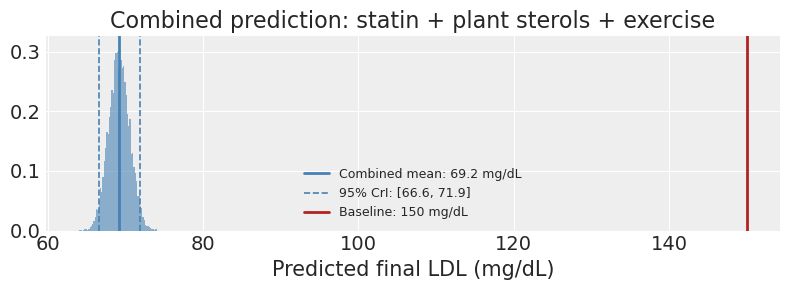

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(result['ldl_final'], bins=60, density=True, alpha=0.6, color='steelblue')
ax.axvline(final_mean, color='steelblue', linewidth=2,
           label=f'Combined mean: {final_mean:.1f} mg/dL')
ax.axvline(final_lo, color='steelblue', linewidth=1.2, linestyle='--')
ax.axvline(final_hi, color='steelblue', linewidth=1.2, linestyle='--',
           label=f'95% CrI: [{final_lo:.1f}, {final_hi:.1f}]')
ax.axvline(BASELINE_LDL, color='firebrick', linewidth=2,
           label=f'Baseline: {BASELINE_LDL:.0f} mg/dL')
ax.set_xlabel('Predicted final LDL (mg/dL)')
ax.set_title('Combined prediction: statin + plant sterols + exercise')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()